**Name : Shravani Borde**

**Roll no. : C2-36**

**NLP LAB**

**PRACTICAL NO 8**

**Aim**: Write the python code to perform sentiment analysis using NLP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install nltk

In [3]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"

df = pd.read_csv(url)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
import re

def clean_text(text):

    text = text.lower()
    text = re.sub("<.*?>","",text)
    text = re.sub("[^a-zA-Z]"," ",text)

    return text

df["review"] = df["review"].apply(clean_text)

In [6]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is...,positive


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["review"],
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [10]:
lr = LogisticRegression()
nb = MultinomialNB()
svm = LinearSVC()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
nb.fit(X_train, y_train)
svm.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [12]:
def evaluate_model(model):

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, pos_label="positive")
    rec = recall_score(y_test, y_pred, pos_label="positive")
    f1 = f1_score(y_test, y_pred, pos_label="positive")

    return acc, pre, rec, f1, y_pred

lr_acc, lr_pre, lr_rec, lr_f1, lr_pred = evaluate_model(lr)
nb_acc, nb_pre, nb_rec, nb_f1, nb_pred = evaluate_model(nb)
svm_acc, svm_pre, svm_rec, svm_f1, svm_pred = evaluate_model(svm)
rf_acc, rf_pre, rf_rec, rf_f1, rf_pred = evaluate_model(rf)

In [13]:
comparison = pd.DataFrame({

    "Model": ["Logistic Regression", "Naive Bayes", "SVM", "Random Forest"],
    "Accuracy": [lr_acc, nb_acc, svm_acc, rf_acc],
    "Precision": [lr_pre, nb_pre, svm_pre, rf_pre],
    "Recall": [lr_rec, nb_rec, svm_rec, rf_rec],
    "F1 Score": [lr_f1, nb_f1, svm_f1, rf_f1]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9021,0.894603,0.9116,0.903021
1,Naive Bayes,0.8763,0.870155,0.8846,0.877318
2,SVM,0.9057,0.900020,0.9128,0.906365
3,Random Forest,0.8634,0.867071,0.8584,0.862714


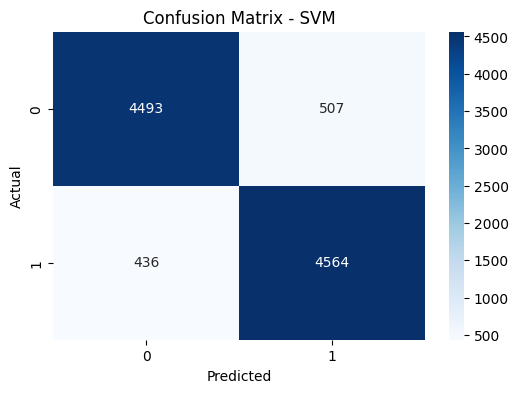

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [15]:
import pickle

pickle.dump(svm, open("sentiment_model.pkl","wb"))
pickle.dump(tfidf, open("tfidf.pkl","wb"))